# Анализ медицинских данных

## Набор 2: диабет

В этой тетрадке:
- исследование данных, пропуски/аномалии
- корреляционный и визуальный анализ
- подготовка признаков
- логистическая регрессия, метрики, рок‑кривая
- коэффициенты и функция `predict_diabetes`
- подбор гиперпараметров (бонус)


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

sns.set_theme()


## Задание 4. Загрузка и исследование данных

По заданию файл: `src/diabetes.csv`.


In [2]:
from pathlib import Path

candidates = [
    Path("diabetes.csv"),
    Path("src/diabetes.csv"),
    Path("diabetes222.csv"),
    Path("src/diabetes222.csv"),
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Не найден diabetes.csv (или diabetes222.csv).")

print("Использую файл:", data_path)

df = pd.read_csv(data_path)
df.head()


Использую файл: diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isna().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### 0 как «нет данных» (обработка аномалий)

Заменяем 0→NaN в колонках, где 0 физически невозможен.


In [6]:
zero_as_nan_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for c in zero_as_nan_cols:
    if c in df.columns:
        df.loc[df[c] == 0, c] = np.nan

df[zero_as_nan_cols].isna().sum()


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

## Задание 5. Корреляционный анализ и визуализация

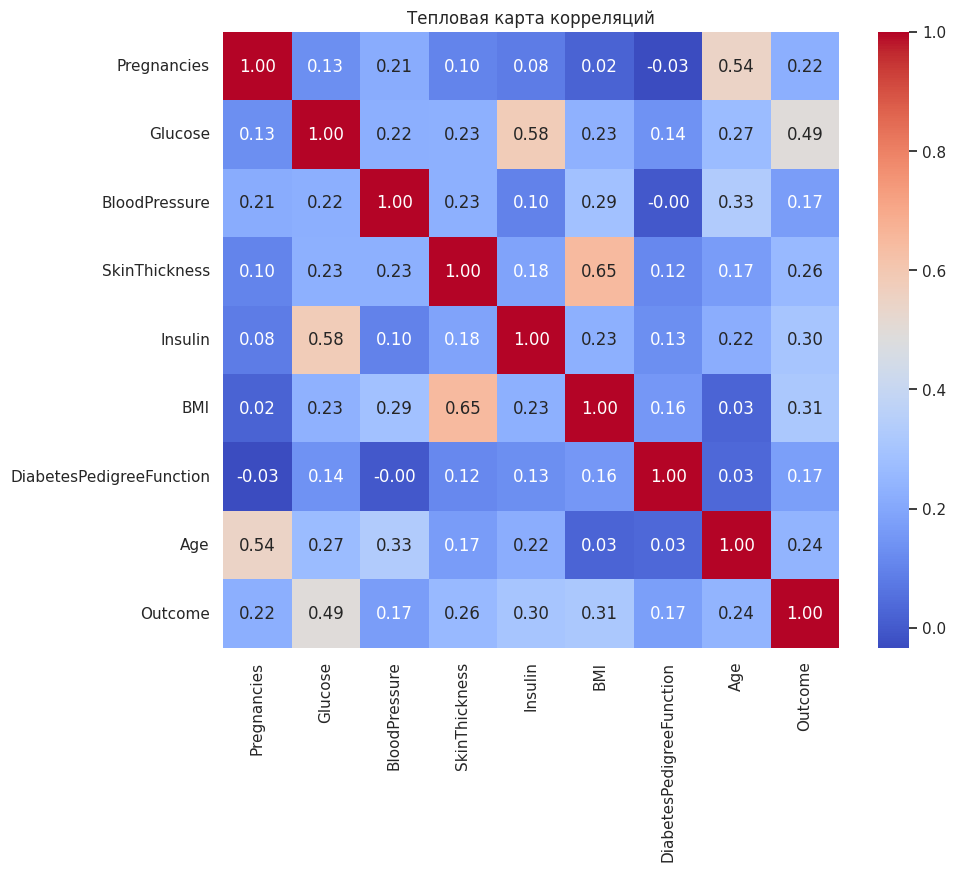

In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Тепловая карта корреляций")
plt.show()


In [8]:
top = (
    corr["Outcome"]
    .drop(index=["Outcome"])
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top


Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

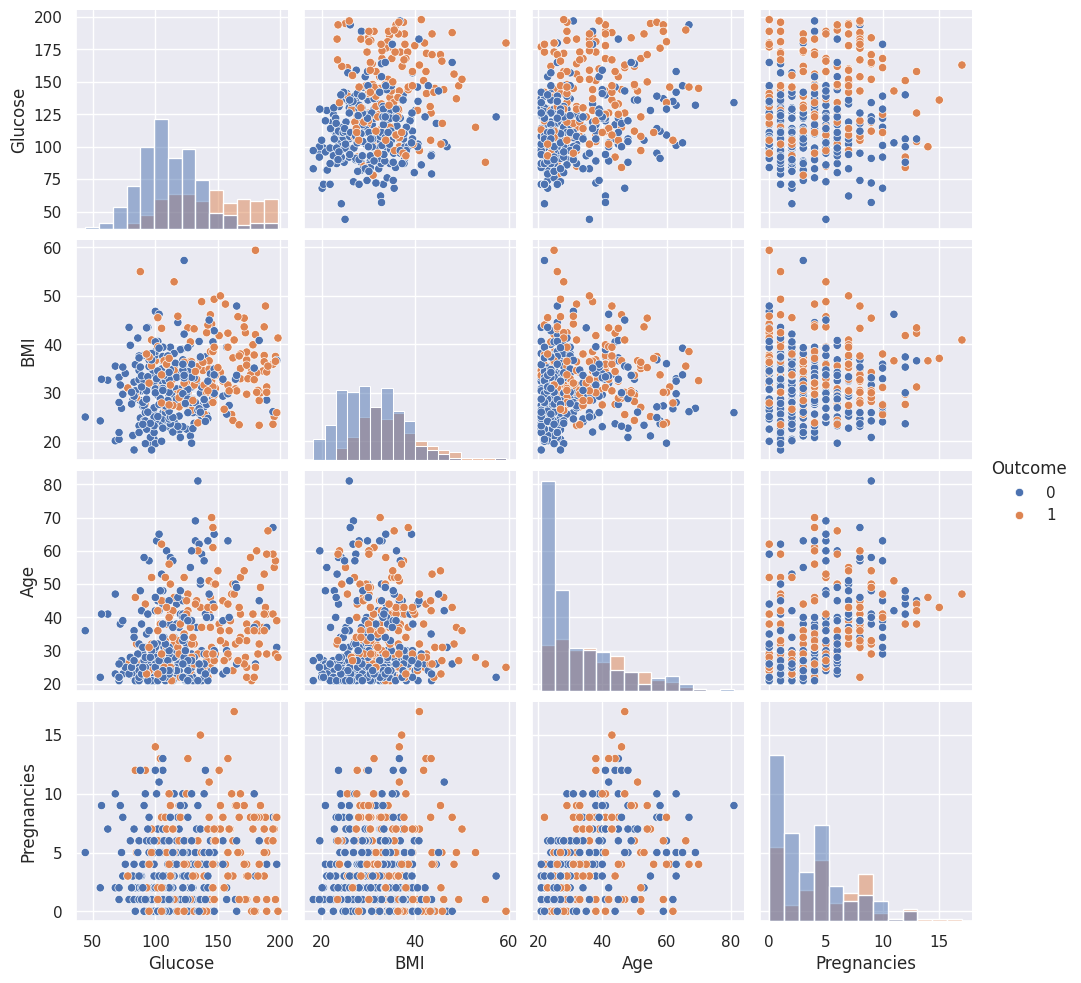

In [9]:
cols = [c for c in ["Glucose", "BMI", "Age", "Pregnancies", "Outcome"] if c in df.columns]
sample = df[cols].dropna().sample(n=min(400, len(df[cols].dropna())), random_state=42)

sns.pairplot(sample, hue="Outcome", diag_kind="hist")
plt.show()


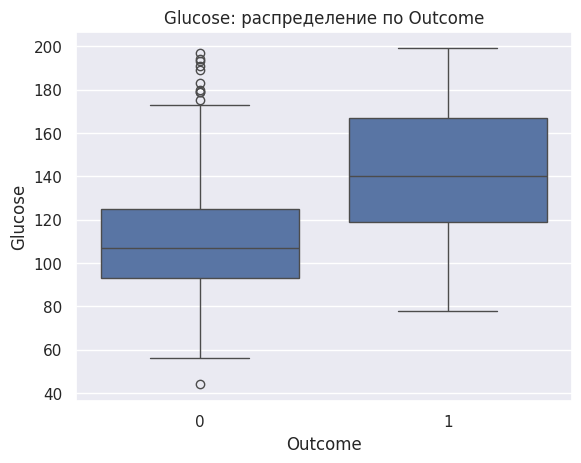

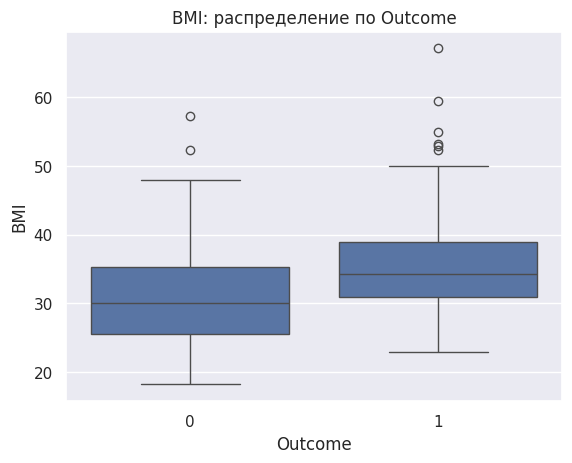

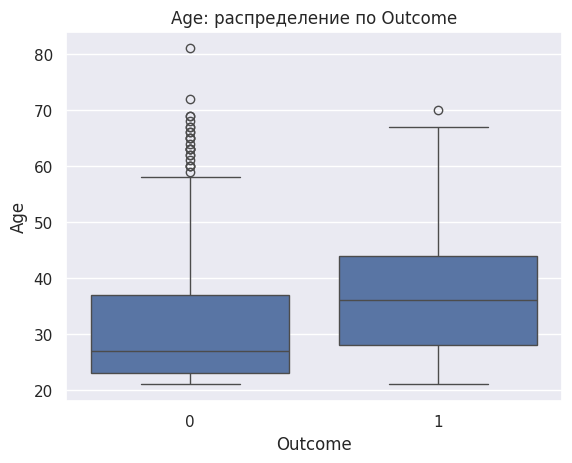

In [10]:
for feat in [c for c in ["Glucose", "BMI", "Age"] if c in df.columns]:
    plt.figure()
    sns.boxplot(data=df, x="Outcome", y=feat)
    plt.title(f"{feat}: распределение по Outcome")
    plt.show()


## Задание 6–7. Подготовка данных и базовая модель

In [11]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Доля класса 1:")
print("  train:", round(y_train.mean(), 3))
print("  test :", round(y_test.mean(), 3))


Доля класса 1:
  train: 0.348
  test : 0.351


In [12]:
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, solver="liblinear"))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print("Метрики на тесте:")
print("  accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("  precision:", round(precision_score(y_test, y_pred, zero_division=0), 3))
print("  recall   :", round(recall_score(y_test, y_pred, zero_division=0), 3))
print("  f1       :", round(f1_score(y_test, y_pred, zero_division=0), 3))
print("  roc-auc  :", round(roc_auc_score(y_test, y_proba), 3))


Метрики на тесте:
  accuracy : 0.745
  precision: 0.672
  recall   : 0.531
  f1       : 0.593
  roc-auc  : 0.836


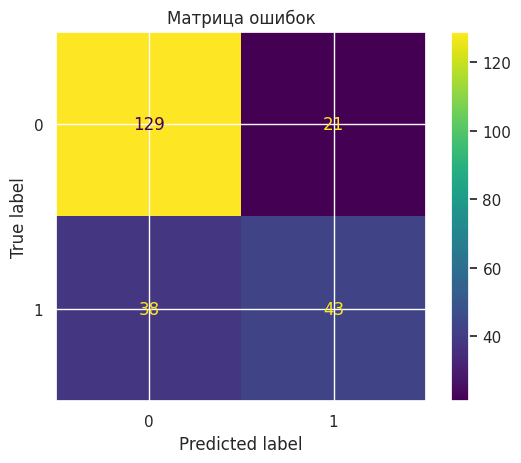

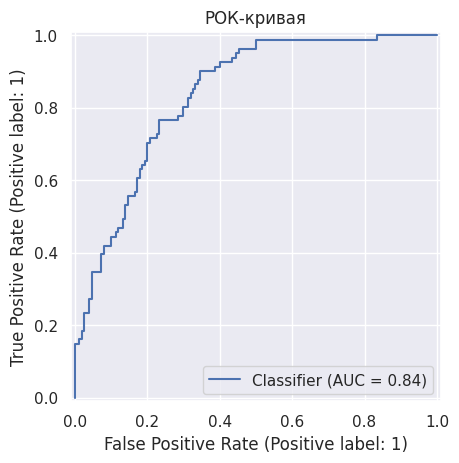

In [13]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Матрица ошибок")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("РОК-кривая")
plt.show()


## Задание 8. Коэффициенты и функция предсказания

In [14]:
feature_names = X.columns.to_list()
coef = pipe.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({"признак": feature_names, "коэффициент": coef})
coef_df["|коэффициент|"] = coef_df["коэффициент"].abs()
coef_df.sort_values("|коэффициент|", ascending=False).head(10)


,признак,коэффициент,|коэффициент|
1,Glucose,1.125337,1.125337
5,BMI,0.732802,0.732802
0,Pregnancies,0.459968,0.459968
6,DiabetesPedigreeFunction,0.215096,0.215096
7,Age,0.100595,0.100595
3,SkinThickness,-0.092660,0.092660
2,BloodPressure,-0.041486,0.041486
4,Insulin,-0.033628,0.033628


In [15]:
def predict_diabetes(
    pregnancies, glucose, blood_pressure, skin_thickness, insulin,
    bmi, diabetes_pedigree_function, age,
    model_pipe=pipe
):
    row = pd.DataFrame([{
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "BloodPressure": blood_pressure,
        "SkinThickness": skin_thickness,
        "Insulin": insulin,
        "BMI": bmi,
        "DiabetesPedigreeFunction": diabetes_pedigree_function,
        "Age": age
    }])

    for c in zero_as_nan_cols:
        if c in row.columns:
            row.loc[row[c] == 0, c] = np.nan

    proba = model_pipe.predict_proba(row)[:, 1][0]
    pred = int(proba >= 0.5)
    return proba, pred

proba, pred = predict_diabetes(2, 150, 80, 20, 100, 30, 0.5, 35)
print("Вероятность:", round(proba, 3), "класс:", pred)


Вероятность: 0.448 класс: 0


## Бонус: GridSearchCV

In [18]:
from sklearn.linear_model import LogisticRegression

param_grid = {
    "model__C": [0.01, 0.1, 1, 3, 10, 30],
    "model__l1_ratio": [0, 1],
}

grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        
        ("model", LogisticRegression(
            max_iter=5000, 
            solver="saga",  
            penalty='elasticnet' 
        ))
    ]),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший roc-auc (cv):", round(grid.best_score_, 3))


/mnt/c/Users/drpsi/Projects/SamiraSber/Data_analysis_03_ITS.ID_1549196-1/src/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/mnt/c/Users/drpsi/Projects/SamiraSber/Data_analysis_03_ITS.ID_1549196-1/src/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/mnt/c/Users/drpsi/Projects/SamiraSber/Data_analysis_03_ITS.ID_1549196

Лучшие параметры: {'model__C': 1, 'model__l1_ratio': 0}
Лучший roc-auc (cv): 0.836


/mnt/c/Users/drpsi/Projects/SamiraSber/Data_analysis_03_ITS.ID_1549196-1/src/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/mnt/c/Users/drpsi/Projects/SamiraSber/Data_analysis_03_ITS.ID_1549196-1/src/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [17]:
best_pipe = grid.best_estimator_

y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print("Метрики лучшей модели на тесте:")
print("  accuracy :", round(accuracy_score(y_test, y_pred_best), 3))
print("  precision:", round(precision_score(y_test, y_pred_best, zero_division=0), 3))
print("  recall   :", round(recall_score(y_test, y_pred_best, zero_division=0), 3))
print("  f1       :", round(f1_score(y_test, y_pred_best, zero_division=0), 3))
print("  roc-auc  :", round(roc_auc_score(y_test, y_proba_best), 3))


Метрики лучшей модели на тесте:
  accuracy : 0.745
  precision: 0.672
  recall   : 0.531
  f1       : 0.593
  roc-auc  : 0.836
